In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.optimize import curve_fit
import os

# prof = lambda x, A, alpha, xt, b: A * np.tanh(alpha * (x - xt)) + b


(128, 128)


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1200.

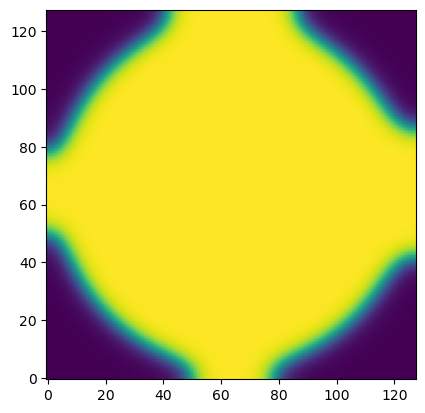

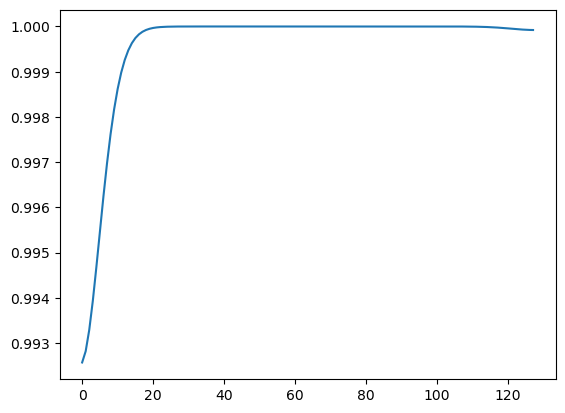

In [28]:
prof = lambda x, A, alpha, x0, x1, b: A * (np.tanh(alpha * (x - x0)) + np.tanh(-alpha * (x - x1))) + b


dir = 'outputs/nucleation_2d\sig_8.5_rbm_2.25\sim_data_20260412_210730/data.h5'
with h5py.File(dir, 'r') as f:
    psi_hist = f['solution/psi_hist'][:]
    # Gamma = f.attrs['parameters/lam_psi'][()]
    # R = f.attrs['parameters/rbm'][()]
    # D_psi = f.attrs['parameters/D_psi'][]


nt, nx, ny = np.shape(psi_hist)
lim = nx // 2


t = -1
plt.imshow(psi_hist[t], origin='lower', vmin=-1, vmax=1)
plt.figure()
print(np.shape(psi_hist[t]))
psi_t = np.mean(psi_hist[t][60:68, :], axis=0)
plt.plot(psi_t)
params, _ = curve_fit(prof, np.arange(len(psi_t)), psi_t, p0=[0.5, 1.0, 25, 80, 0.1])
print(params)
plt.plot(prof(np.arange(len(psi_t)), *params), ls='--')

xt = []

for t in range(50, nt):
    try:
        psi_t = np.mean(psi_hist[t][:, :], axis=0)
        params, _ = curve_fit(prof, np.arange(len(psi_t)), psi_t, p0=[1.0, 1.0, 10, 0.1])
        xt.append(params[2])
    except:
        pass

print(xt)

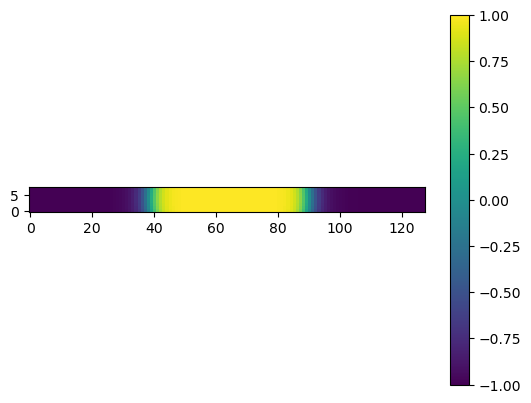

In [10]:
plt.imshow(psi_hist[10, 60:68, :], origin='lower', vmin=-1, vmax=1)
plt.colorbar()

# Pseudo phase diagram

In [33]:
import os
import h5py
import numpy as np
from scipy.optimize import curve_fit

# prof = lambda x, A, alpha, x0, x1, b: A * (np.tanh(alpha * (x - x0)) + np.tanh(-alpha * (x - x1))) + b
prof = lambda x, A, alpha, xt, b: A * np.tanh(alpha * (x - xt)) + b



base_dir = "outputs/nucleation_D0.1"
results = []

dx = 1 / 64

for sim_dir in sorted(os.listdir(base_dir)):
    base_dir2 = os.path.join(base_dir, sim_dir)
    for sim_dir2 in sorted(os.listdir(base_dir2)):
        full_dir = os.path.join(base_dir2, sim_dir2)
        if not os.path.isdir(full_dir):
            continue

        # Find data.h5 (or all *.h5) in that folder
        possible_h5 = [f for f in os.listdir(full_dir) if f.endswith(".h5")]
        if not possible_h5:
            continue

        h5_path = os.path.join(full_dir, possible_h5[0])
        with h5py.File(h5_path, "r") as f:
            if "solution/psi_hist" not in f:
                continue
            psi_hist = f["solution/psi_hist"][:]
            if psi_hist.ndim not in (2,3):
                continue

            # final state
            psi_final = psi_hist[-1]
            # Use threshold instead of isclose (more lenient for floating point)
            has_ones = np.any(psi_final > 0.90)
            max_psi = np.max(psi_final)
            frac_ones = np.mean(psi_final > 0.90)
            try:
                params, _ = curve_fit(prof, np.arange(len(psi_final[0])), np.mean(psi_final, axis=0), p0=[0.5, 1.0, 5, 0.1])
                # length = (params[3] - params[2]) * dx
                length = params[2] * dx
            except:
                length = 0


            results.append((sim_dir, sim_dir2, has_ones, max_psi, length))

# print summary
print(f"{'Group':<30} {'Simulation':<40} {'psi>0.90':<10} {'max(psi)':<10} {'length':<10}")
print("-" * 100)
for group, sim_dir, has_ones, max_psi, length in results:
    print(f"{group:<30} {sim_dir:<40} {str(has_ones):<10} {max_psi:<10.6f} {length:<10.4e}")

total = len(results)
with_ones = sum(1 for r in results if r[2])
print(f"\nScanned {total} sims, {with_ones} have psi>0.90 at final state.")


Group                          Simulation                               psi>0.90   max(psi)   length    
----------------------------------------------------------------------------------------------------
sig_0.5_rbm_0.15               sim_data_20260415_143544                 False      -0.861459  5.8654e-02
sig_0.5_rbm_0.15               sim_data_20260415_143824                 False      -0.861459  5.8654e-02
sig_0.5_rbm_0.25               sim_data_20260415_143844                 False      -0.746198  5.7337e-02
sig_0.5_rbm_0.35               sim_data_20260415_143910                 False      -0.592108  5.5436e-02
sig_0.5_rbm_0.45               sim_data_20260415_143944                 False      -0.118900  4.9811e-02
sig_0.5_rbm_0.55               sim_data_20260415_144013                 True       0.995860   1.3953e-01
sig_0.5_rbm_0.65               sim_data_20260415_143551                 True       0.996987   1.4511e-01
sig_0.5_rbm_0.65               sim_data_20260415_144035    

Plotted 55 nucleation detection points and 16 no-nucleation points on phase diagram


C:\Users\ppere\AppData\Local\Temp\ipykernel_10136\284946919.py:36: RuntimeWarning: divide by zero encountered in scalar divide
  sig = integral / (rm * np.log(rm / rc) ** (1/2))


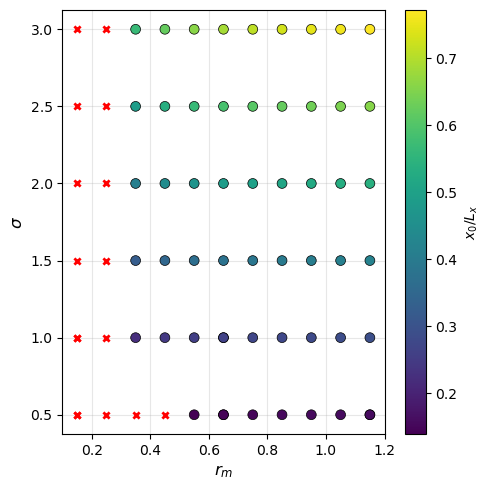

: 

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Plot phase diagram with nucleation detection points overlaid
fig, ax = plt.subplots(figsize=(5, 5))

# Redraw phase diagram
from scipy.integrate import quad
from matplotlib.colors import ListedColormap

def f(psi, rm):
    output = (0.25 * (psi**2 - 1)**2 - 0*rm * psi * (1 - psi/2))
    return output


D = 0.1

rc = 0.25
rm_arr = np.linspace(0.25, 2.0, 100)
# sig_arr = np.linspace(0.01, 5.0, 100)
sig_arr = []
phase = np.zeros((100, 100))

for rm in rm_arr:
    
    def integrand(psi, rm):
        return np.sqrt(np.abs(f(psi, rm)))

    integral, _ = quad(integrand, -1, 1, args=(rm,))
#     for sig in sig_arr:
#         numb = rm * sig * (np.log(rm / rc)) ** (1/2)
#         if integral < numb:
#             phase[np.where(rm_arr == rm), np.where(sig_arr == sig)] = 1
#         else:
#             phase[np.where(rm_arr == rm), np.where(sig_arr == sig)] = 0
    sig = integral / (rm * np.log(rm / rc) ** (1/2))
    # sig = np.log(rm / rc) ** (-1/2)
    sig_arr.append(sig)

# im = ax.imshow(phase.T, origin='lower', extent=(rm_arr[0], rm_arr[-1], sig_arr[0], sig_arr[-1]), 
#                aspect='auto', cmap='RdYlBu_r', alpha=0.7)

# Extract and plot nucleation points from results
nucleation_points_rm = []
nucleation_points_sig = []
nucleation_points_length = []
no_nucleation_points_rm = []
no_nucleation_points_sig = []

for group, sim_dir, has_ones, max_psi, length in results:
    # Parse group name: 'sig_X_rbm_Y'
    parts = group.split('_')
    try:
        sig_idx = parts.index('sig')
        rbm_idx = parts.index('rbm')
        sig_val = float(parts[sig_idx + 1])
        rbm_val = float(parts[rbm_idx + 1])
        
        if has_ones:  # Nucleation detected
            nucleation_points_sig.append(sig_val)
            nucleation_points_rm.append(rbm_val)
            nucleation_points_length.append(length)
        else:  # No nucleation detected
            no_nucleation_points_sig.append(sig_val)
            no_nucleation_points_rm.append(rbm_val)
    except (ValueError, IndexError):
        pass

# Create interpolation grid for level curves
if nucleation_points_rm:
    # Create a fine grid for interpolation
    rm_grid = np.linspace(min(nucleation_points_rm) - 0.05, max(nucleation_points_rm) + 0.05, 100)
    sig_grid = np.linspace(min(nucleation_points_sig) - 0.05, max(nucleation_points_sig) + 0.05, 100)
    rm_mesh, sig_mesh = np.meshgrid(rm_grid, sig_grid)
    
    # Interpolate length values onto the grid
    points = np.array([nucleation_points_rm, nucleation_points_sig]).T
    values = np.array(nucleation_points_length)
    # length_interp = griddata(points, values, (rm_mesh, sig_mesh), method='cubic')
    
    # # Add contour line for x_0/L_x = 0.3
    # contour = ax.contour(rm_mesh, sig_mesh, length_interp, levels=[0.3], colors='red', 
    #                      linewidths=2, linestyles='--', label=r'$x_0/L_x = 0.3$')
    # ax.clabel(contour, inline=True, fontsize=10, fmt=r'$x_0/L_x=0.3$')


# Plot detected nucleation points (colored by length)
if nucleation_points_rm:
    scatter = ax.scatter(nucleation_points_rm, nucleation_points_sig , c=nucleation_points_length, 
                        s=50, marker='o', edgecolors='black', linewidth=0.5, 
                        cmap='viridis', label=r'Diff. ($\psi>0.90$)', zorder=5)
    cbar = plt.colorbar(scatter, ax=ax, label=r'$x_0 / L_x$')

# Plot no nucleation points (red)
if no_nucleation_points_rm:
    ax.scatter(no_nucleation_points_rm, no_nucleation_points_sig, color='red', s=20, 
               marker='x', linewidth=2, label='No diff.', zorder=5)

ax.set_xlabel(r'$r_m$', fontsize=12)
ax.set_ylabel(r'$\sigma$', fontsize=12)
# ax.axvline(rc, color='black', linestyle='--', alpha=0.5, label=r'$r_c$')

# ax.plot(rm_arr, sig_arr, label='Eq.', ls='--', color='black')


# # Shinkring length
# contour = ax.contour(rm_mesh, sig_mesh, length_interp, levels=[0.5], colors='red', 
#                         linewidths=2, linestyles='--', label=r'$x_0/L_x = 0.5$')
# ax.clabel(contour, inline=True, fontsize=10, fmt=r'$x_0/L_x=0.5$')
# plt.text(0.7, 0.31, "Shrink", color='black', fontsize=12, ha='center', va='center', transform=ax.transAxes)
# plt.text(0.7, 0.75, "Expand", color='black', fontsize=12, ha='center', va='center', transform=ax.transAxes)

# ax.legend(loc='upper right')
ax.grid(alpha=0.3)



plt.tight_layout()
# plt.ylim(0.45, 2.05)
# plt.xlim(0.20, 1.55)
# plt.savefig('phase_diagram.png', dpi=300)

# ax.contour(rm_mesh, sig_mesh, np.sqrt(np.pi / 2) * rm_mesh * sig_mesh, levels=[ 1, 2], colors='blue', 
                        # linewidths=2, linestyles='--', label=r'$x_0/L_x = 0.3$')

print(f"Plotted {len(nucleation_points_rm)} nucleation detection points and {len(no_nucleation_points_rm)} no-nucleation points on phase diagram")
